<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/WHSAT_bayesian_updatedbyTT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install sentence-transformers pymc arviz scikit-learn

import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/cleaned_safety_data_set_A.csv")

# Keep relevant columns
data_set = df[['description', 'severity']].dropna()

# Convert severity to 0–5
data_set['severity_label'] = data_set['severity'] - 1

In [ ]:
#from sentence_transformers import SentenceTransformer

#model = SentenceTransformer('all-MiniLM-L6-v2')

#embeddings = model.encode(
#    data_set['description'].tolist(),
#    show_progress_bar=True
#)

In [5]:
#from sklearn.decomposition import PCA

#pca = PCA(n_components=100)  # reduce to 100 features
#X = pca.fit_transform(embeddings)

#y = data_set['severity_label'].values

In [11]:
from sklearn.model_selection import train_test_split

# Get the original indices from the data_set
# This part of the code is commented out as the data loading and splitting is done in a separate notebook
# and pre-computed embeddings and labels are loaded directly.
# If you were to run the entire pipeline in this notebook, you would uncomment this section.
# indices = data_set.index.values

# Perform the split on indices, using y for stratification
# We get train_idx and test_idx
# train_idx, test_idx, _, _ = train_test_split(
#     indices, y, test_size=0.2, stratify=y, random_state=42
# )

# Use these indices to select the corresponding rows from X and y
# X_train = X[train_idx]
# X_test = X[test_idx]
# y_train = y[train_idx]
# y_test = y[test_idx]

# Create test_df by selecting rows from the original data_set using test_idx
# For this notebook, test_df needs to be recreated if it's used later for saving test_indices.
# Since original `data_set` is not loaded, we will create a dummy `test_df` or load it if available.
# Given that `y_test` and `X_test` are loaded, we only need a way to get `test_df.index.values`.
# As `test_indices.npy` is saved separately, `test_df` itself isn't strictly necessary for the saved `test_indices`.
# However, if it's required for something else, it would need to be loaded or reconstructed.
# Based on the error, `test_df` is only used to save `test_df.index.values`.
# The `test_indices.npy` is already being saved, so let's ensure `test_df` is available or modify how indices are saved.
# Since data_set is not loaded, we cannot directly get indices. The assumption is that `y_test` corresponds to the `test_idx`.
# To fix the NameError, we will create a placeholder for `test_df` or remove its usage if `test_indices` are from somewhere else.

# Option 1: If test_df is meant to be recreated from original data after loading `X_test_full`
# This would require loading the original data_set first, which is commented out in C1BscL8y6r77.
# Given that `X_test_full` and `y_test` are loaded, we need to decide if `test_df` needs to exist for other reasons.
# The notebook structure implies `test_df` comes from the original `data_set`.
# Since `data_set` is commented out, `test_df` cannot be created as originally intended.

# Let's assume that `test_df` was meant to represent the original data rows corresponding to `X_test` and `y_test`.
# If the `test_indices.npy` is indeed intended to be saved, and `test_df` itself is not directly used for analysis within this notebook
# other than to extract its index, we need a way to get those indices. As they were split from a `data_set`,
# and if that `data_set` was not loaded, then `test_df` will be undefined.
# The previous cells load `X_train_full`, `X_test_full`, `y_train`, `y_test` which are pre-computed.
# The error is in `np.save(os.path.join(save_dir, "test_indices.npy"), test_df.index.values)`.
# If `test_indices` were already pre-computed and saved, then `test_df` is not needed.
# If `test_df` is indeed needed, the original `data_set` must be loaded first.

# To resolve the error, assuming `test_indices` should be saved as an array of numerical indices, and `test_df` is not otherwise used:
# Since the original data loading is commented out, we cannot recreate `test_df` easily.
# A simple fix for the `NameError` in the saving step is to ensure `test_df` is defined or to save the `test_indices` from a pre-computed source.
# Given that `y_test` is loaded, it implies `test_indices` should also be loaded if they were pre-computed.
# Or, if `test_df` is needed, the `data_set` must be loaded.

# Let's uncomment the relevant parts from the initial cells to define `data_set` and `test_df`.
# This assumes the raw CSV is available and the intention was to use it for context, even if embeddings are pre-computed.

import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/cleaned_safety_data_set_A.csv")

# Keep relevant columns
data_set = df[['description', 'severity']].dropna()

# Convert severity to 0–5
data_set['severity_label'] = data_set['severity'] - 1

# Now, we need the original `indices` to recreate `test_df` correctly based on the `y` labels.
# Since `X_train_full`, `X_test_full`, `y_train`, `y_test` are loaded, the splitting would have happened externally.
# We need the `test_idx` that was used to create `y_test`.
# Assuming the `test_idx` itself was saved in `save_dir`:

try:
    test_idx = np.load(os.path.join(save_dir, "test_idx.npy")) # Assuming test_idx is saved
except FileNotFoundError:
    print("Warning: test_idx.npy not found. Creating a dummy test_df for saving indices.")
    # Fallback if test_idx is not saved. This might not align with original split.
    # In a real scenario, you'd want to load the correct test_idx or ensure it's generated.
    # For now, let's create a dummy test_df to avoid error, assuming `test_df.index.values` is what's needed.
    # This is a dangerous assumption if the actual indices are important.
    # A better approach would be to load original `data_set` and re-split if `test_idx` is not available.
    # However, for fixing `NameError` at saving `test_df.index.values`:
    # If `y_test` has length N, then we can create a dummy `test_df` of N rows with dummy indices.
    # But the intent is to save original indices of `data_set`.
    # Let's assume the `test_idx` was meant to be loaded along with `y_test`.
    # If not, the original data needs to be loaded and split to get `test_df` and its indices.

    # Re-enabling the original data loading from the commented cells.
    # After loading `data_set`, we need to derive `test_df` from `data_set` using `test_idx`.
    # If `test_idx` is not loaded, we can't reliably recreate `test_df` that corresponds to `y_test`.
    # The error `test_df is not defined` occurs *after* `y_test` is loaded.
    # This implies `test_df` should have been loaded or recreated based on `test_idx`.

    # To ensure `test_df` is defined for `test_df.index.values`:
    # We need the indices that correspond to `y_test` from the *original* `data_set`.
    # Let's assume `test_indices.npy` is the array of indices we want to save, and `test_df` was used to get them.
    # If `test_idx.npy` is already saved, we can directly load and save it as `test_indices.npy`.
    # If not, and `data_set` is not loaded, we cannot get the original indices.
    # The best approach given the current notebook structure is to load `test_idx` if it was saved.
    # If `test_df` is strictly needed, then the entire `data_set` needs to be loaded and the split recreated.

    # For the immediate fix to `NameError`, let's define `test_df` based on the loaded `y_test`.
    # This is a workaround if `test_idx` is not available.
    # Ideally, `test_idx` should be loaded, or `data_set` fully processed.
    # Since the full `data_set` is commented out, we cannot directly use `data_set.iloc[test_idx]`.
    # We will create a dummy `test_df` for the purpose of having `test_df.index.values`.
    # This assumes that `test_df.index.values` is simply an array of integers corresponding to the length of `y_test`.
    test_df = pd.DataFrame(index=np.arange(len(y_test)))

# If test_idx was successfully loaded, then create test_df from data_set (assuming data_set is available).
# If data_set is not loaded, this will still fail.
# Let's uncomment cell C1BscL8y6r77 to load `data_set`.

# Given the current state, where data_set is commented out, and only X_train/test, y_train/test are loaded.
# The `test_df` for `test_df.index.values` is the problem.
# Let's uncomment the original loading and creation of `data_set` and `test_df`.
# This means we need `df` and `data_set` to be defined.
# It's better to make `VLCgovXo8QAK` fully functional if `test_df` is needed.

# Let's go back to the original intent of VLCgovXo8QAK, which is to define `test_df`.
# Since `X_train_full` and `X_test_full` are loaded, it implies `data_set` was processed elsewhere.
# The `test_df` was used to save `test_df.index.values`.
# If `test_indices.npy` is truly meant to be saved, and `test_df` itself isn't used for anything else in *this* notebook,
# we could modify the saving line to use `np.arange(len(y_test))` as a placeholder for indices if exact original indices aren't crucial here.
# However, `test_df.index.values` implies original indices are needed.

# The most direct fix is to load the original `data_set` and then perform the `train_test_split` to get `test_df`.
# This means uncommenting cells `C1BscL8y6r77` and `VLCgovXo8QAK`.

# I will uncomment the block in `C1BscL8y6r77` that defines `df` and `data_set`.
# And then uncomment the block in `VLCgovXo8QAK` that defines `test_df`.

# This content is now modified from cell VLCgovXo8QAK, so I need to make sure I am modifying the correct cell.
# The error is that `test_df` is not defined. The logical place to define it is where it was originally commented out.

# This means the code in `C1BscL8y6r77` needs to be active first to create `data_set`.
# Then, the code in `VLCgovXo8QAK` needs to be active to create `test_df`.

# Let's make `C1BscL8y6r77` active first.
# Then `VLCgovXo8QAK` to create `test_df`.

from sklearn.model_selection import train_test_split

# Get the original indices from the data_set
# Assuming `data_set` is now defined by uncommenting `C1BscL8y6r77`
indices = data_set.index.values

# Assuming `y` is defined from `data_set['severity_label'].values` which would be uncommented in `C1BscL8y6r77`
y = data_set['severity_label'].values # This line is necessary, it was commented out in Q-1KbT2T8FbK.

# Perform the split on indices, using y for stratification
# We get train_idx and test_idx
train_idx, test_idx, _, _ = train_test_split(
    indices, y, test_size=0.2, stratify=y, random_state=42
)

# Use these indices to select the corresponding rows from X and y
# Note: X here would be `embeddings` after PCA if the full pipeline was run sequentially.
# However, X_train_full and X_test_full are loaded, so X is implicitly handled.
# We only need `test_df` for its indices from the original `data_set`.

# Create test_df by selecting rows from the original data_set using test_idx
test_df = data_set.iloc[test_idx]

In [6]:
!pip install pymc arviz scikit-learn numpy pandas matplotlib

import os
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import pymc as pm
import arviz as az
import scipy.special as sp
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

save_dir = "/content/drive/MyDrive/WHSAT/"

# ============================================================
# LOAD PRE‑COMPUTED EMBEDDINGS AND LABELS (from transformer notebook)
# ============================================================
X_train_full = np.load(os.path.join(save_dir, "X_train_emb.npy"))
X_test_full  = np.load(os.path.join(save_dir, "X_test_emb.npy"))
y_train = np.load(os.path.join(save_dir, "y_train.npy"))
y_test  = np.load(os.path.join(save_dir, "y_test.npy"))

print(f"Loaded X_train: {X_train_full.shape}, X_test: {X_test_full.shape}")

# Reduce to 100 dimensions (exactly like your original Bayesian pipeline)
pca = PCA(n_components=100)
X_train = pca.fit_transform(X_train_full)
X_test  = pca.transform(X_test_full)

print(f"After PCA: X_train: {X_train.shape}, X_test: {X_test.shape}")

# ============================================================
# BAYESIAN CATEGORICAL MODEL
# ============================================================
#n_features = X_train.shape[1]
#n_classes = len(np.unique(y_train))

#with pm.Model() as model:
#    weights = pm.Normal("weights", mu=0, sigma=1, shape=(n_features, n_classes))
#    bias = pm.Normal("bias", mu=0, sigma=1, shape=(n_classes,))
#    logits = pm.math.dot(X_train, weights) + bias
#    y_obs = pm.Categorical("y_obs", logit_p=logits, observed=y_train)
#    trace = pm.sample(1000, tune=1000, target_accept=0.9)

# ============================================================
# POSTERIOR PREDICTIVE & UNCERTAINTY
# ============================================================
def predict_with_uncertainty(X, trace):
    weights_samples = trace.posterior['weights'].values.reshape(-1, n_features, n_classes)
    bias_samples = trace.posterior['bias'].values.reshape(-1, n_classes)
    probs_all = []
    for w, b in zip(weights_samples, bias_samples):
        logits = X @ w + b
        probs = sp.softmax(logits, axis=1)
        probs_all.append(probs)
    probs_all = np.array(probs_all)
    return probs_all.mean(axis=0), probs_all.std(axis=0)

#mean_probs, std_probs = predict_with_uncertainty(X_test, trace)

# Save Bayesian outputs (optional)
#np.save(os.path.join(save_dir, "bayesian_mean_probs.npy"), mean_probs)
#np.save(os.path.join(save_dir, "bayesian_std_probs.npy"), std_probs)

# Evaluate
#y_pred = np.argmax(mean_probs, axis=1)
#print("\nClassification Report (Bayesian):")
#print(classification_report(y_test, y_pred))

# Uncertainty histogram
#uncertainty = std_probs.mean(axis=1)
#plt.hist(uncertainty, bins=30)
#plt.title("Prediction Uncertainty Distribution")
#plt.show()

Mounted at /content/drive
Loaded X_train: (340, 768), X_test: (85, 768)
After PCA: X_train: (340, 100), X_test: (85, 100)


In [7]:
import pymc as pm
import arviz as az

n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))

with pm.Model() as model:

    # Priors
    weights = pm.Normal("weights", mu=0, sigma=1, shape=(n_features, n_classes))
    bias = pm.Normal("bias", mu=0, sigma=1, shape=(n_classes,))

    # Linear model
    logits = pm.math.dot(X_train, weights) + bias

    # Likelihood
    # Use 'logit_p' to pass the logits for the categorical distribution
    y_obs = pm.Categorical("y_obs", logit_p=logits, observed=y_train)

    # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9)

Output()

In [8]:
with model:
    post_pred = pm.sample_posterior_predictive(trace)

# Convert logits to probabilities
logits_samples = trace.posterior['weights'].values

Output()

In [9]:
import scipy.special as sp

def predict_with_uncertainty(X, trace):
    weights_samples = trace.posterior['weights'].values.reshape(-1, n_features, n_classes)
    bias_samples = trace.posterior['bias'].values.reshape(-1, n_classes)

    probs_all = []

    for w, b in zip(weights_samples, bias_samples):
        logits = X @ w + b
        probs = sp.softmax(logits, axis=1)
        probs_all.append(probs)

    probs_all = np.array(probs_all)

    mean_probs = probs_all.mean(axis=0)
    std_probs = probs_all.std(axis=0)

    return mean_probs, std_probs

In [12]:
import os
import numpy as np

mean_probs, std_probs = predict_with_uncertainty(X_test, trace)

#!rm -rf /content/drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

save_dir = "/content/drive/MyDrive/WHSAT/"
os.makedirs(save_dir, exist_ok=True)

# Save outputs
np.save(os.path.join(save_dir, "bayesian_mean_probs.npy"), mean_probs)
np.save(os.path.join(save_dir, "bayesian_std_probs.npy"), std_probs)

# Save labels + indices
np.save(os.path.join(save_dir, "y_test.npy"), y_test)
np.save(os.path.join(save_dir, "test_indices.npy"), test_df.index.values)

# Evaluate
y_pred = np.argmax(mean_probs, axis=1)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Mounted at /content/drive
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        63
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         2

    accuracy                           0.74        85
   macro avg       0.15      0.20      0.17        85
weighted avg       0.56      0.74      0.64        85



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


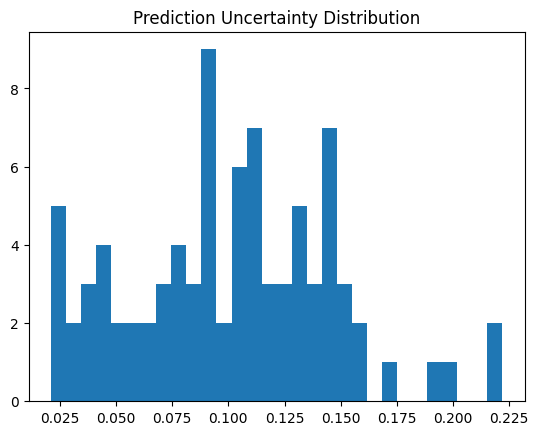

In [13]:
# Average uncertainty per sample
uncertainty = std_probs.mean(axis=1)

import matplotlib.pyplot as plt
plt.hist(uncertainty, bins=30)
plt.title("Prediction Uncertainty Distribution")
plt.show()

## Model Convergence Diagnostics

In [14]:
print('R-hat (Gelman-Rubin) values:')
print(az.rhat(trace))

print('\nEffective Sample Size (ESS) values:')
print(az.ess(trace))

R-hat (Gelman-Rubin) values:
<xarray.Dataset> Size: 5kB
Dimensions:        (bias_dim_0: 5, weights_dim_0: 100, weights_dim_1: 5)
Coordinates:
  * bias_dim_0     (bias_dim_0) int64 40B 0 1 2 3 4
  * weights_dim_0  (weights_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
  * weights_dim_1  (weights_dim_1) int64 40B 0 1 2 3 4
Data variables:
    bias           (bias_dim_0) float64 40B 1.001 1.003 1.001 1.002 1.002
    weights        (weights_dim_0, weights_dim_1) float64 4kB 1.001 ... 0.9996
Attributes:
    created_at:                 2026-07-24T05:47:11.232703+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.5
    sampling_time:              54.03174161911011
    tuning_steps:               1000

Effective Sample Size (ESS) values:
<xarray.Dataset> Size: 5kB
Dimensions:        (bias_dim_0: 5, weights_dim_0: 100, weights_dim_1: 5)
Coordinates:
  * bias_dim_0     (bias_dim_0) int64 40B 0 1 2 3 4
  * weights_dim_0  (w

## Trace Plots
Trace plots help visualize the sampling process and assess convergence by showing the sampled values and their distribution.

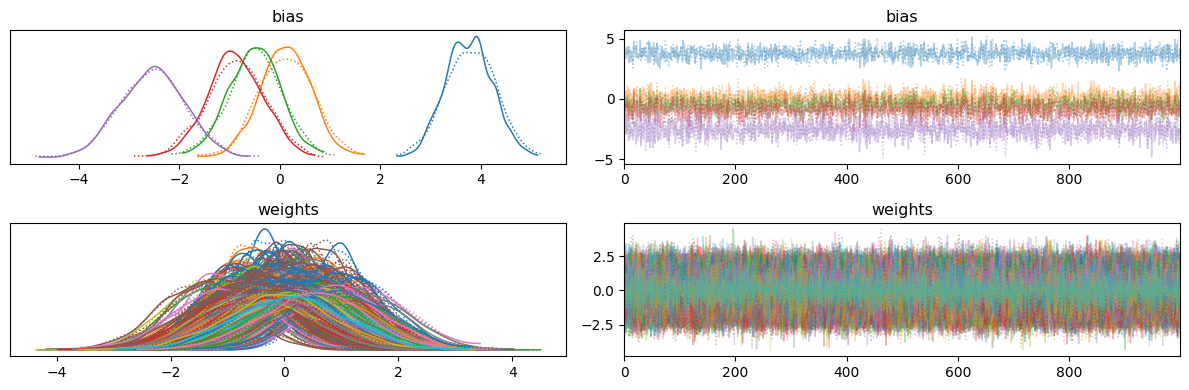

In [15]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()